In [58]:
import torch
import numpy as np
from networks.PeakDetectionModel import PeakDetectionModel
import matplotlib.pyplot as plt
import numpy as np

from run import prepare_dataset

In [59]:
# -------------------- HARD-CODED PARAMETERS --------------------
signal_path = "data/signal.raw"
info_path = "data/info.raw"
chunks = 1024
max_peaks = 3
augment = True
batch_size = 32
shuffle = False
train_split = 0.75
val_split = 0.15

# -------------------- CONFIGURATION --------------------
model_path = "networks\\checkpoints\\model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    augment = augment
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    device = device

args = Config()

print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")


Running inference on device: cuda
Loading model from: networks\checkpoints\model.pt


In [60]:
#-------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

[INFO] Dataset loaded with 50000 signals (augment=True)
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000


In [61]:
# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

PeakDetectionModel(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(15,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=31872, out_features=2048, bias=True)
    (1): ReLU()
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_width): Linear(in_features=2048, out_features=3, bias=True)
  (sigmoid): Sigmoid()
)

In [62]:
# -------------------- INFERENCE --------------------
all_predictions = []
with torch.no_grad():
    for i, (signal, _, _, _) in enumerate(test_loader):
        signal = signal.to(device)
        pred_pos, pred_height, pred_width = model(signal.unsqueeze(1))

        preds = {
            "positions": pred_pos.cpu().numpy(),
            "heights": pred_height.cpu().numpy(),
            "widths": pred_width.cpu().numpy()
        }
        all_predictions.append(preds)

        if i % 10 == 0:
            print(f"Batch {i}: positions {pred_pos.shape}, heights {pred_height.shape}, widths {pred_width.shape}")


Batch 0: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 10: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 20: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 30: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 40: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 50: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 60: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 70: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 80: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 90: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
B

In [63]:

# Print some information
print("Predicted positions (shape):", all_predictions[0]["positions"].shape)
print("Predicted heights (shape):", all_predictions[0]["heights"].shape)
print("Predicted widths (shape):", all_predictions[0]["widths"].shape)

# If you want to see the first 10 values of each prediction
print("\nFirst 10 predicted positions:", all_predictions[0]["positions"][0][:10])
print("First 10 predicted heights:", all_predictions[0]["heights"][0][:10])
print("First 10 predicted widths:", all_predictions[0]["widths"][0][:10])


Predicted positions (shape): (32, 1024)
Predicted heights (shape): (32, 3)
Predicted widths (shape): (32, 3)

First 10 predicted positions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 predicted heights: [0. 0. 0.]
First 10 predicted widths: [0. 0. 0.]


In [64]:
# -------------------- FIRST BATCH AND INFERENCE --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break 


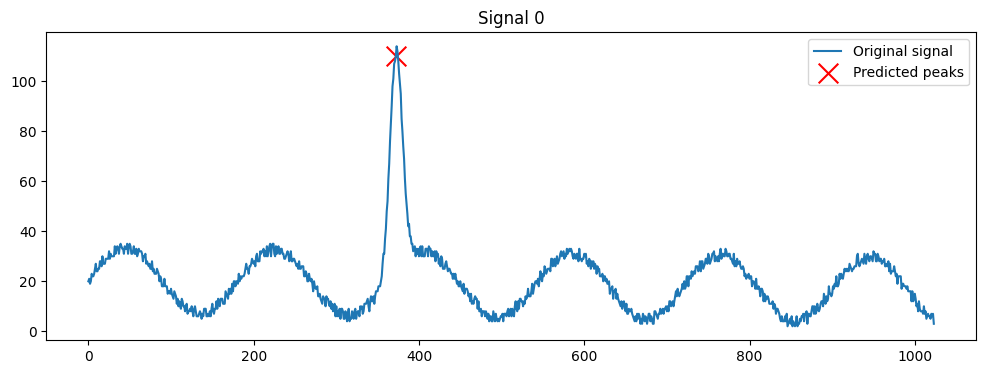

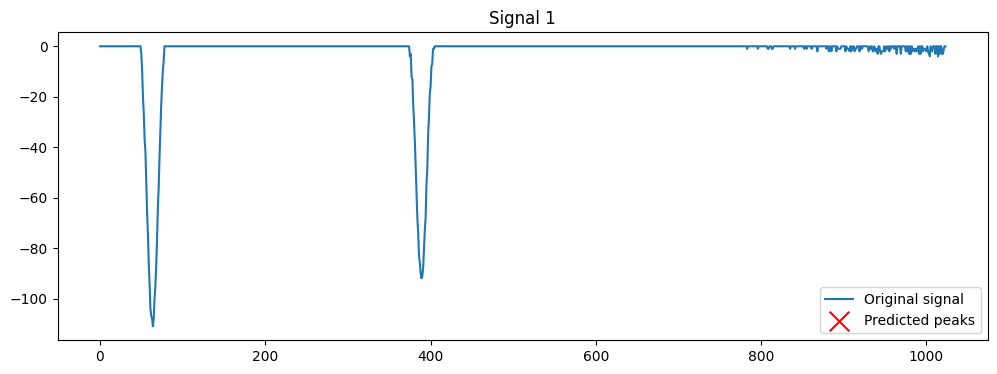

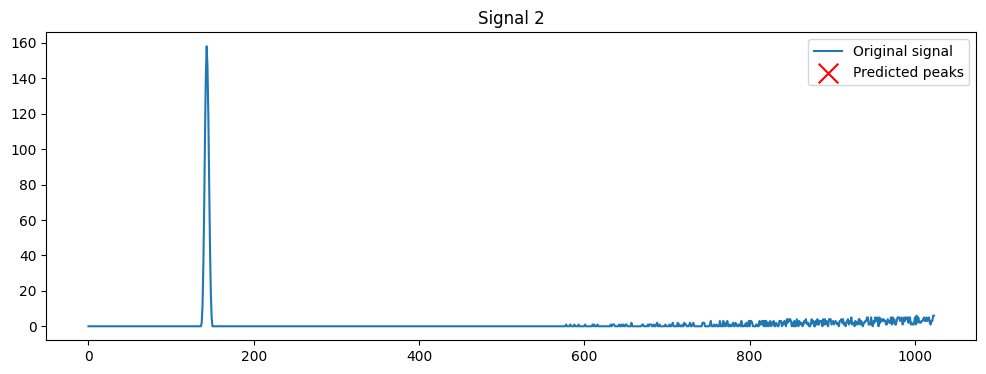

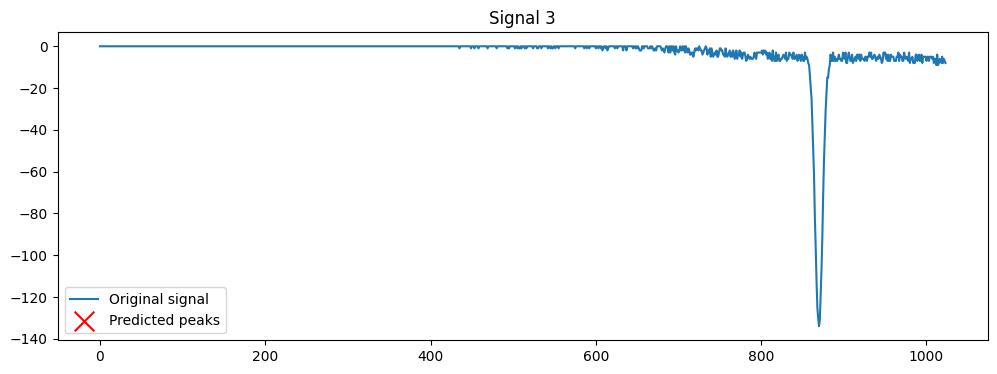

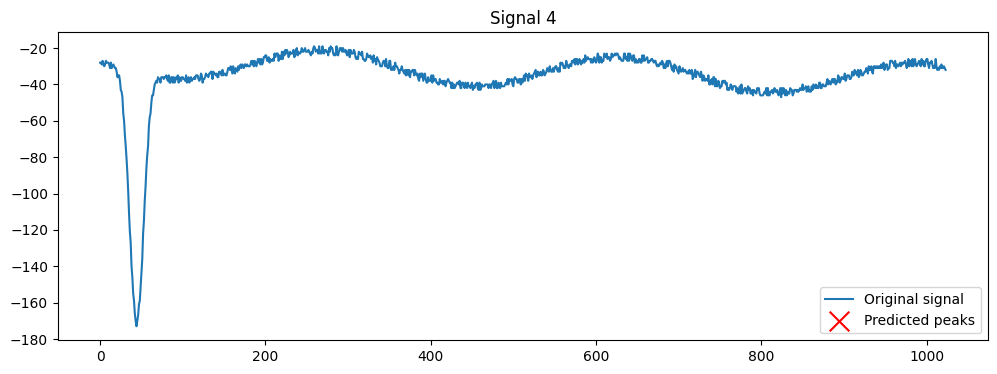

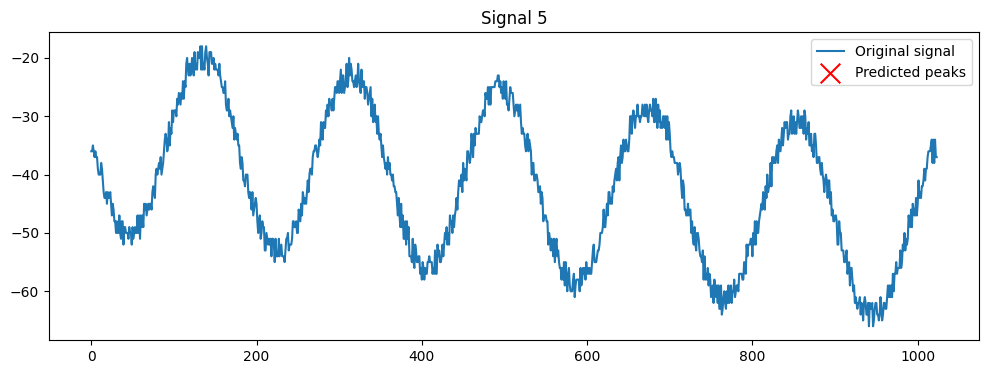

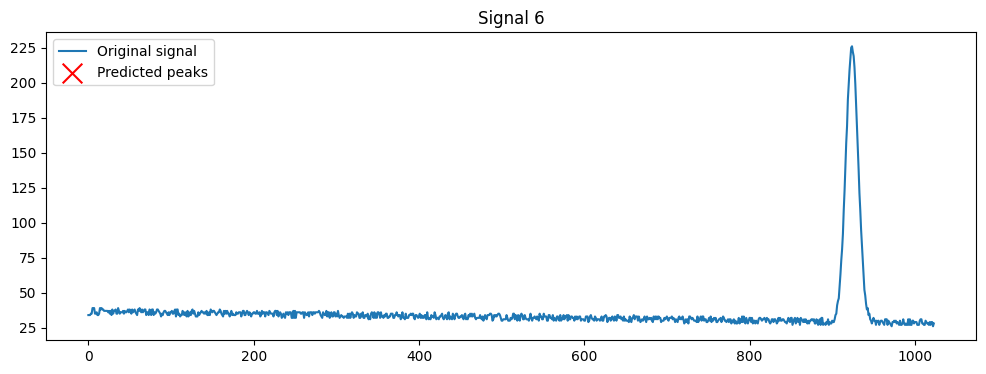

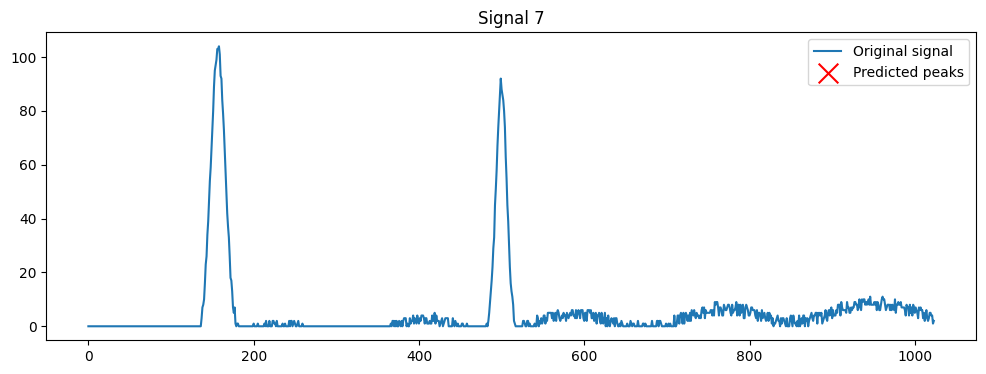

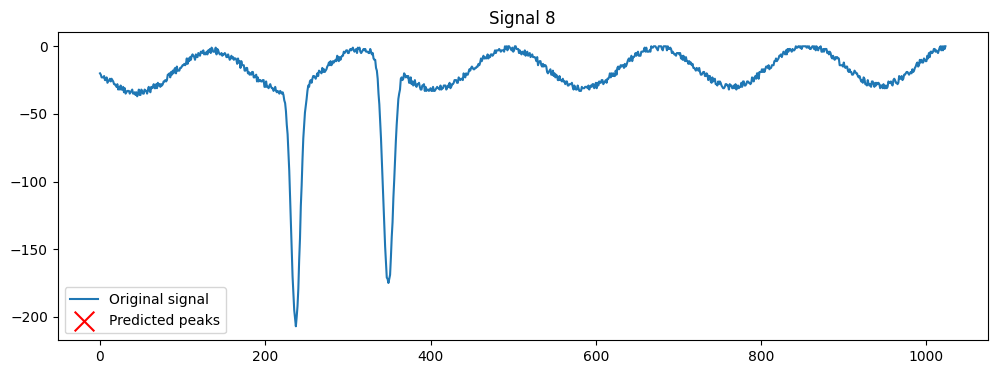

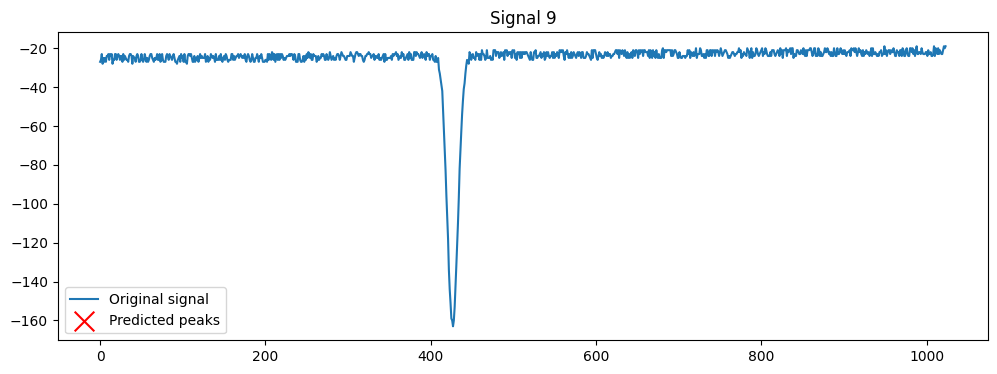

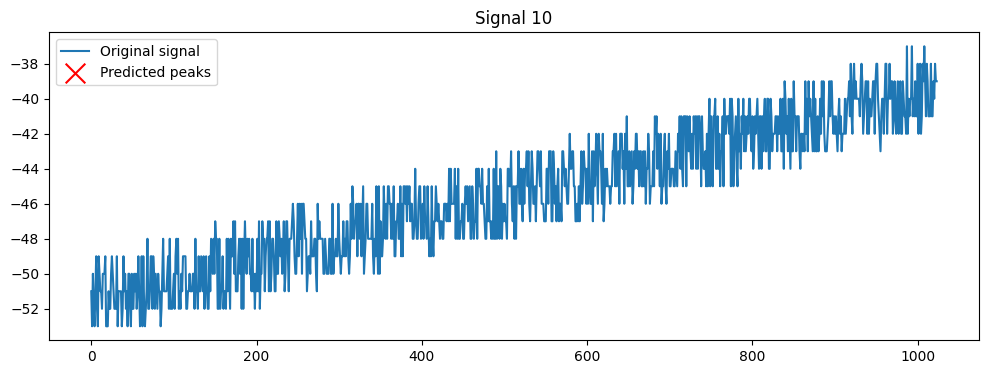

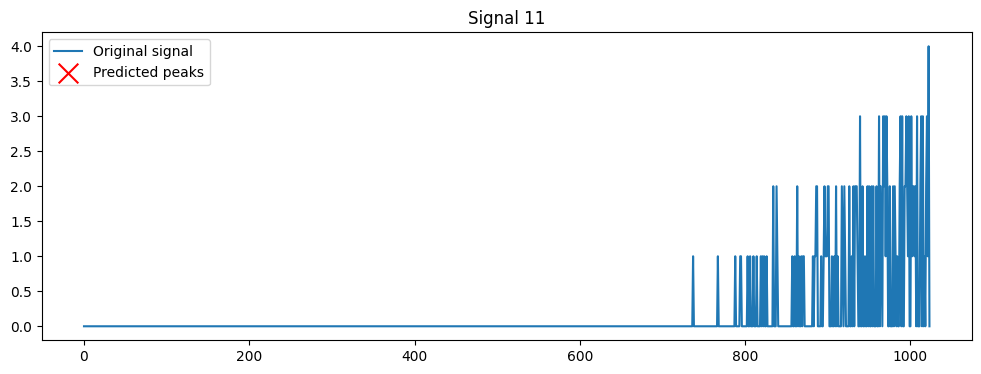

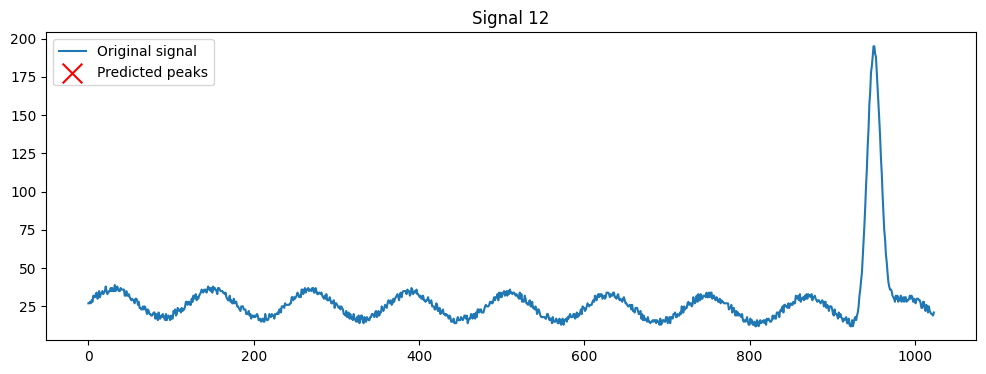

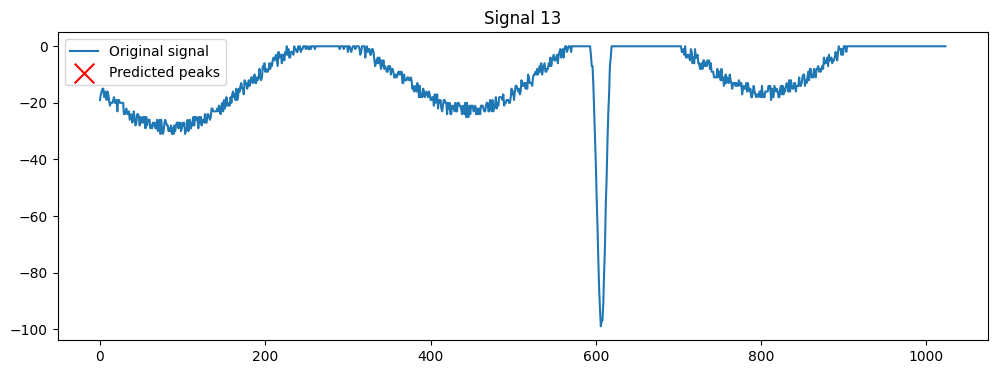

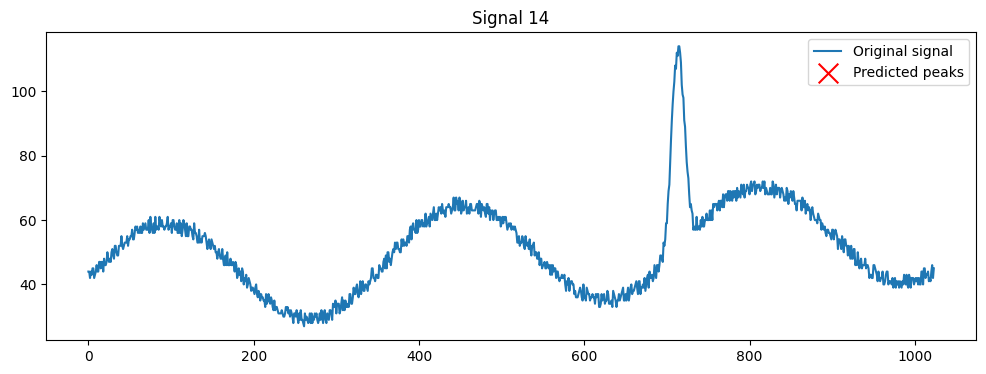

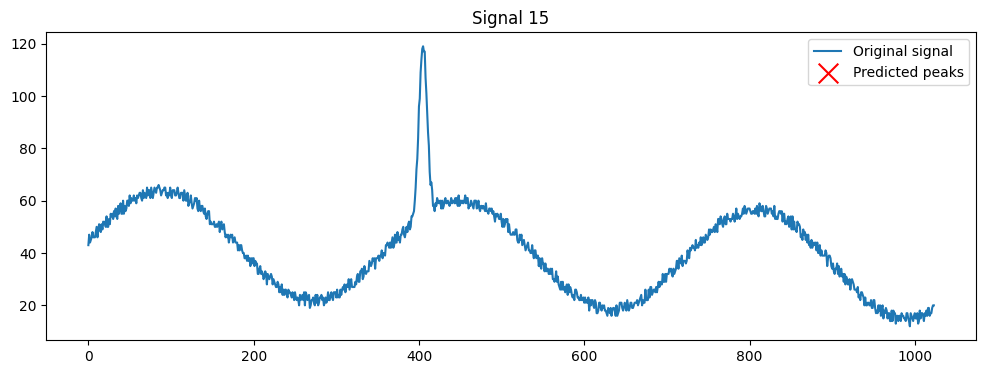

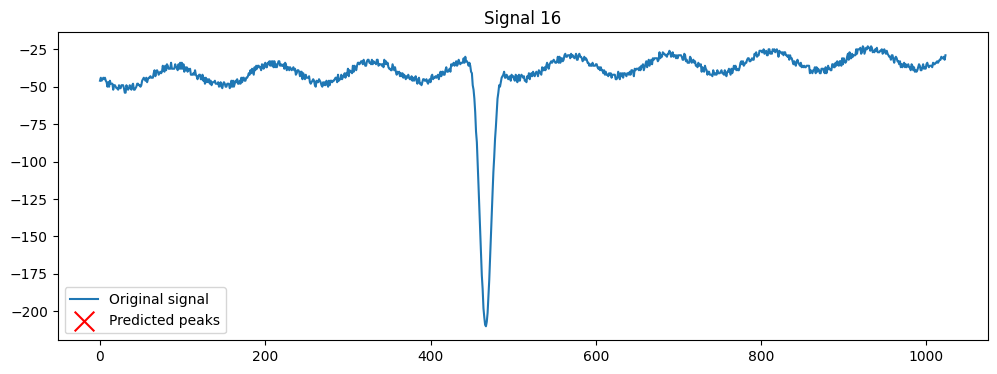

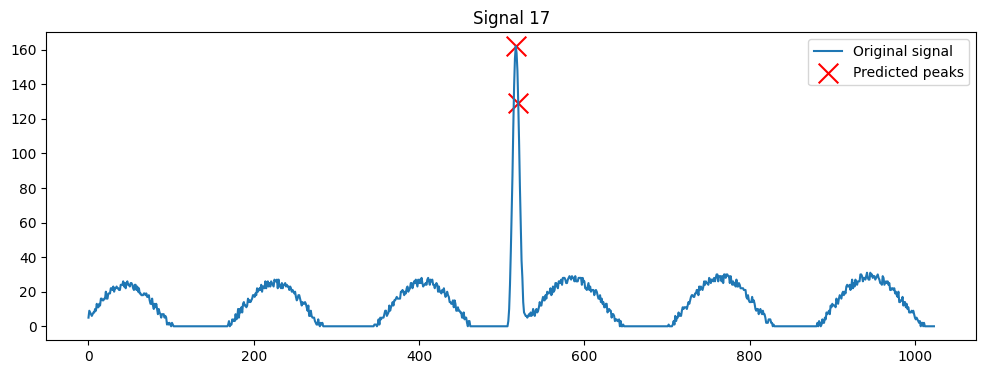

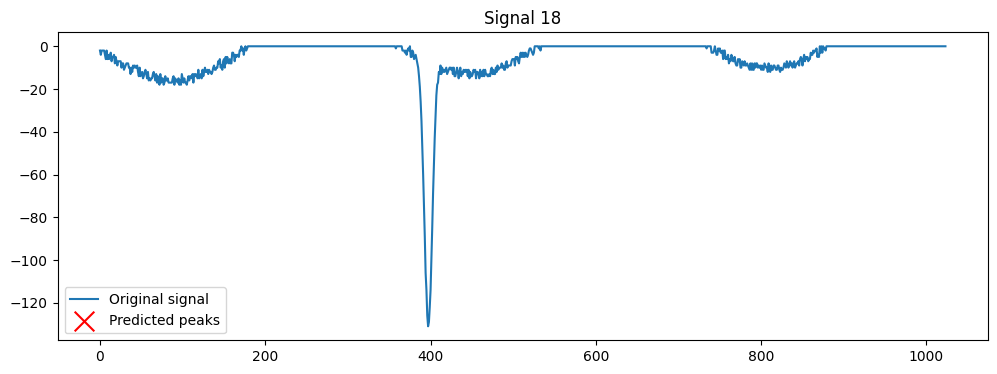

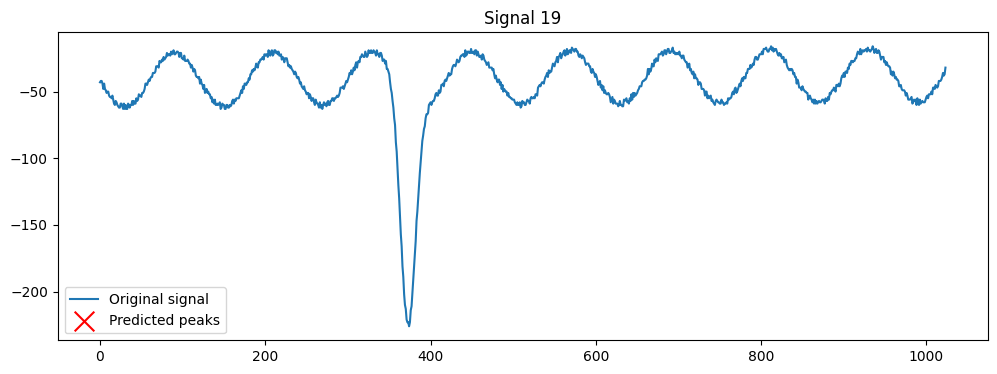

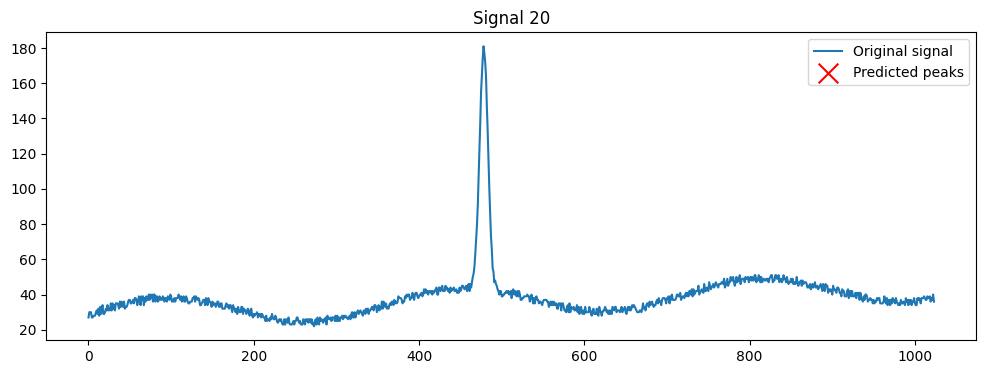

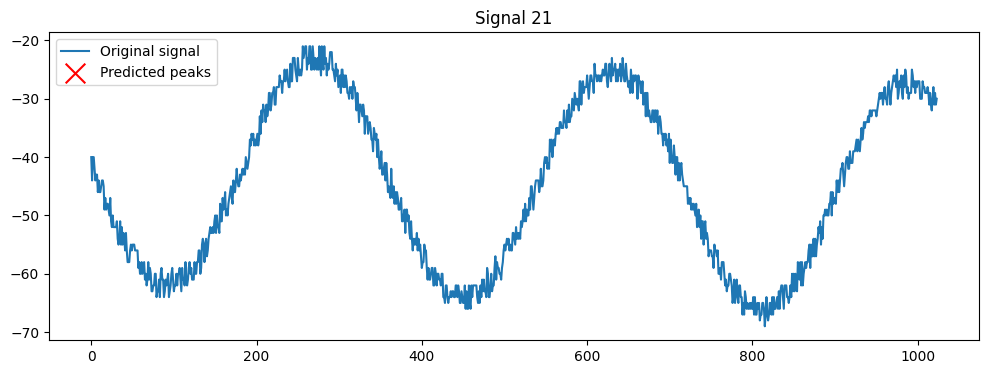

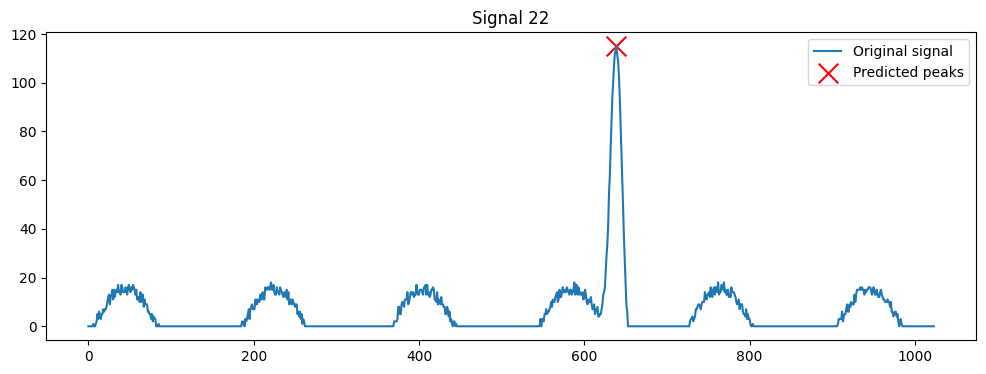

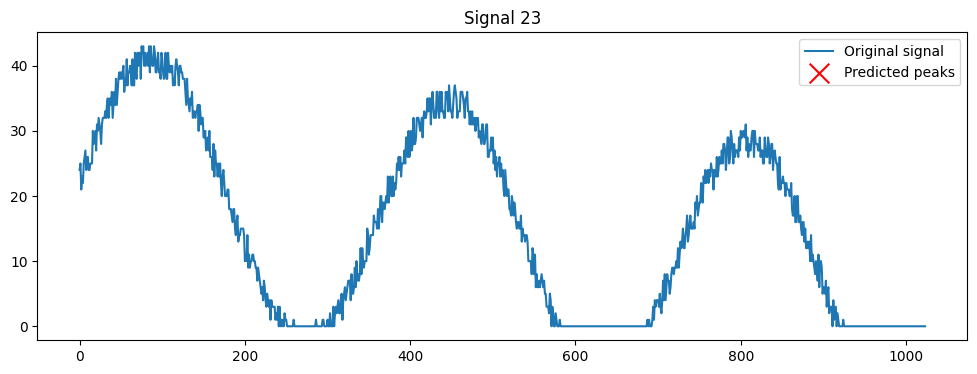

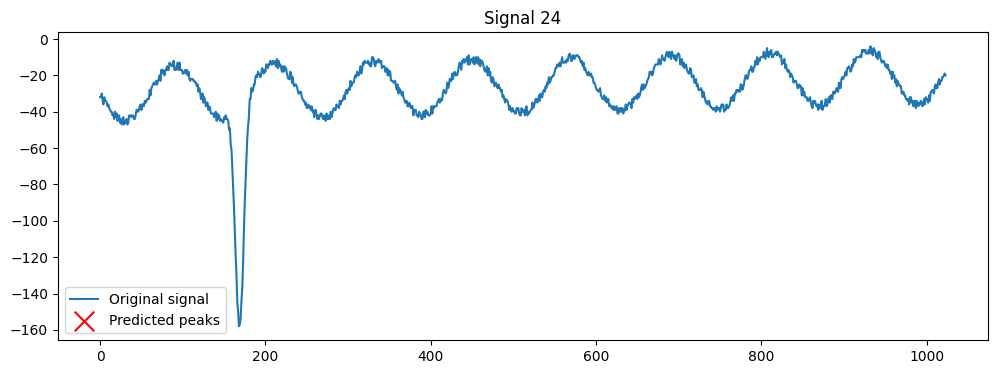

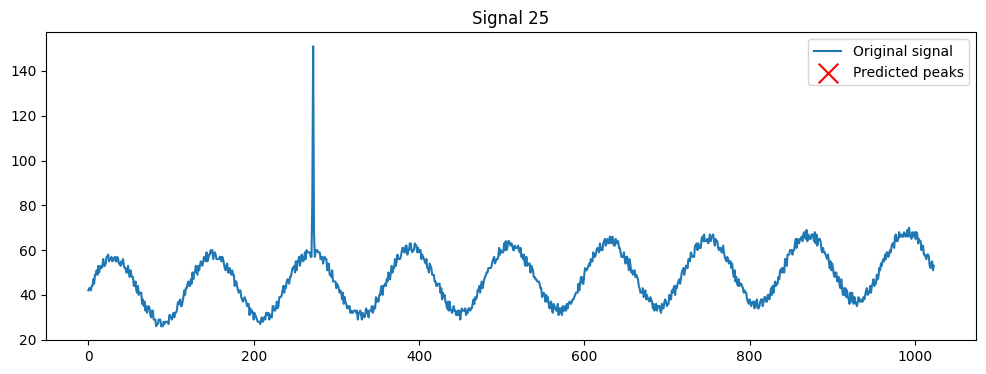

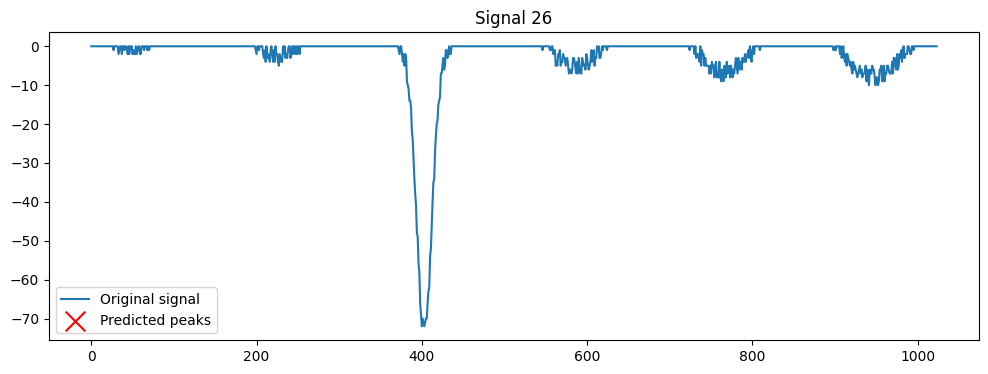

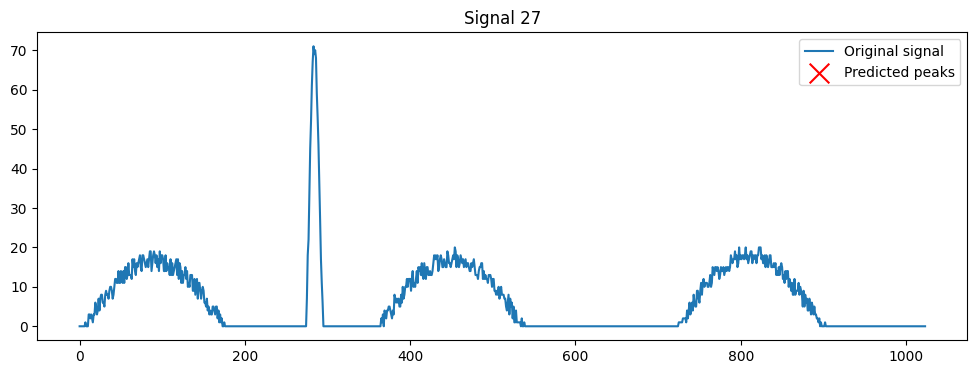

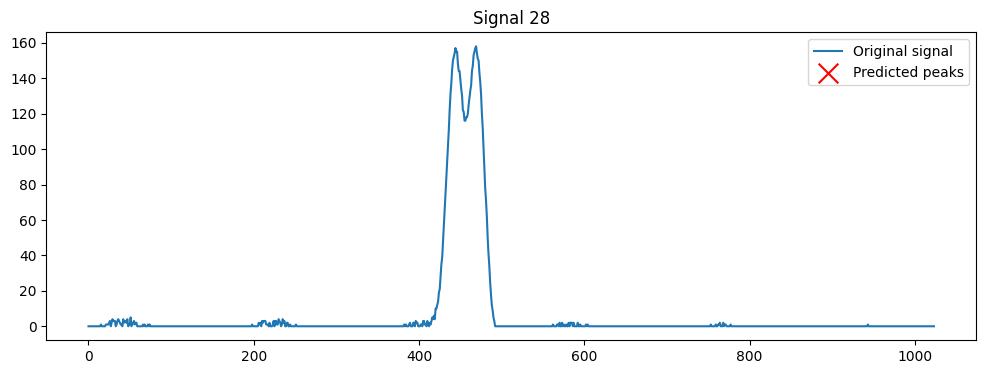

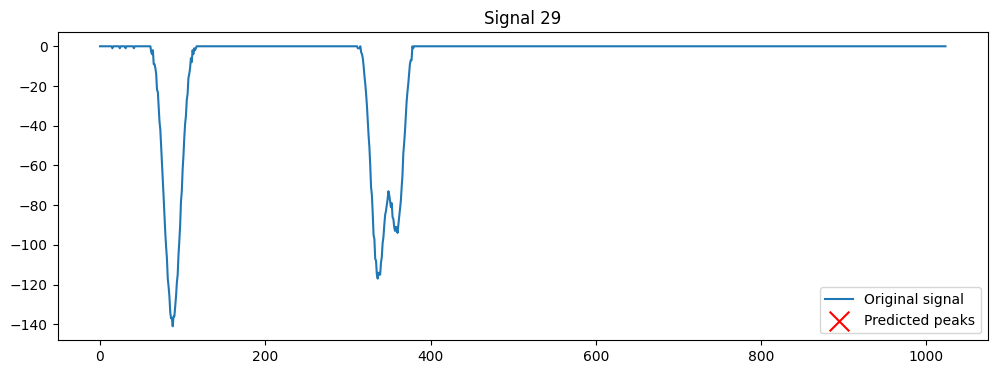

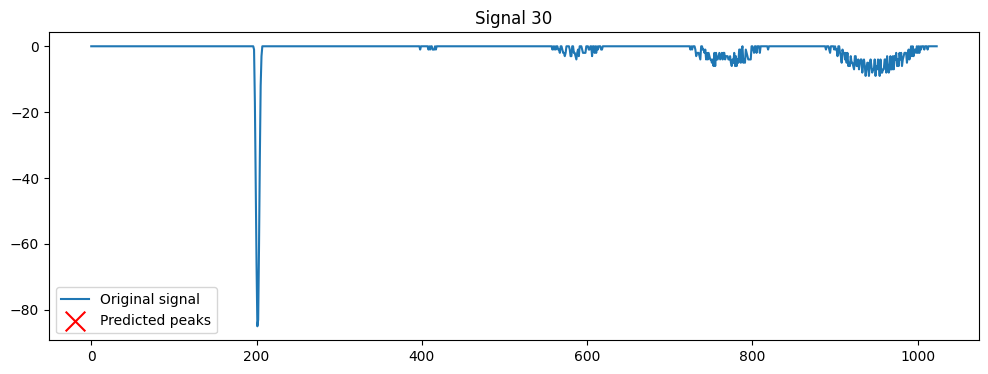

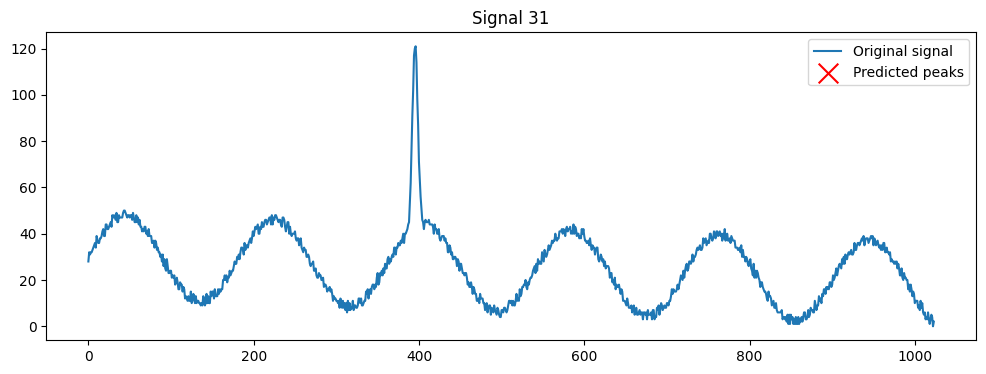

In [65]:
# -------------------- PLOT FIRST 3 SIGNALS --------------------
for i in range(min(50, signals.shape[0])): 
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]
    heights_pred = pred_heights[i]

    plt.figure(figsize=(12,4))
    plt.plot(signal_example, label="Original signal")

    threshold = 0.5
    peak_indices = np.where(positions_pred > threshold)[0]

    plt.scatter(peak_indices, signal_example[peak_indices], s=200, color='r', marker='x', label="Predicted peaks")
    plt.title(f"Signal {i}")
    plt.legend()
    plt.show()